In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
csv_path = "deploy_blockers.csv"
df = pd.read_csv(csv_path)
df.drop(columns=["StagingDeployCash Issue"])

,Deploy Blocker Issue Number,Deploy Blocker GitHub URL,StagingDeployCash Issue Number,StagingDeployCash GitHub URL,StagingDeployCash Created At
0,62669,https://github.com/Expensify/App/issues/62669,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
1,62672,https://github.com/Expensify/App/issues/62672,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
2,62674,https://github.com/Expensify/App/issues/62674,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
3,62675,https://github.com/Expensify/App/issues/62675,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
4,62676,https://github.com/Expensify/App/issues/62676,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
...,...,...,...,...,...
5628,4284,https://github.com/Expensify/App/issues/4284,4279,https://github.com/Expensify/App/issues/4279,2021-07-28
5629,4293,https://github.com/Expensify/App/issues/4293,4279,https://github.com/Expensify/App/issues/4279,2021-07-28
5630,4207,https://github.com/Expensify/App/issues/4207,4198,https://github.com/Expensify/App/issues/4198,2021-07-23
5631,4208,https://github.com/Expensify/App/issues/4208,4198,https://github.com/Expensify/App/issues/4198,2021-07-23


In [4]:
df.head()

,Deploy Blocker Issue Number,Deploy Blocker GitHub URL,StagingDeployCash Issue,StagingDeployCash Issue Number,StagingDeployCash GitHub URL,StagingDeployCash Created At
0,62669,https://github.com/Expensify/App/issues/62669,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
1,62672,https://github.com/Expensify/App/issues/62672,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
2,62674,https://github.com/Expensify/App/issues/62674,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
3,62675,https://github.com/Expensify/App/issues/62675,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
4,62676,https://github.com/Expensify/App/issues/62676,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23


In [5]:
blocker_counts = df.groupby(["StagingDeployCash Issue Number", "StagingDeployCash GitHub URL", "StagingDeployCash Created At"]) \
                   .size().reset_index(name="Deploy Blocker Count")
blocker_counts

,StagingDeployCash Issue Number,StagingDeployCash GitHub URL,StagingDeployCash Created At,Deploy Blocker Count
0,4198,https://github.com/Expensify/App/issues/4198,2021-07-23,3
1,4279,https://github.com/Expensify/App/issues/4279,2021-07-28,2
2,4333,https://github.com/Expensify/App/issues/4333,2021-07-30,4
3,4447,https://github.com/Expensify/App/issues/4447,2021-08-06,6
4,4554,https://github.com/Expensify/App/issues/4554,2021-08-11,11
...,...,...,...,...
475,61917,https://github.com/Expensify/App/issues/61917,2025-05-13,55
476,62161,https://github.com/Expensify/App/issues/62161,2025-05-16,23
477,62353,https://github.com/Expensify/App/issues/62353,2025-05-20,14
478,62497,https://github.com/Expensify/App/issues/62497,2025-05-21,29


In [6]:
average_blockers = blocker_counts["Deploy Blocker Count"].mean()
average_blockers

np.float64(11.735416666666667)

In [7]:
df["StagingDeployCash Created At"] = pd.to_datetime(df["StagingDeployCash Created At"])
unique_deploys = df[["StagingDeployCash Issue Number", "StagingDeployCash Created At"]].drop_duplicates()


In [223]:
unique_deploys["Year"] = unique_deploys["StagingDeployCash Created At"].dt.year
unique_deploys["Month"] = unique_deploys["StagingDeployCash Created At"].dt.month

# Group by year and month
deploys_per_month_year = unique_deploys.groupby(["Year", "Month"]).size().reset_index(name="Deploy Count")

deploys_per_month_year.head()

,Year,Month,Deploy Count
0,2021,7,3
1,2021,8,4
2,2021,9,12
3,2021,10,6
4,2021,11,5


In [9]:
average_deploys_per_month = deploys_per_month_year["Deploy Count"].mean()
average_deploys_per_month

np.float64(10.212765957446809)

In [224]:
df["Year"] = df["StagingDeployCash Created At"].dt.year
df["Month"] = df["StagingDeployCash Created At"].dt.month

# Group by year and month, count deploy blockers
blockers_per_month = df.groupby(["Year", "Month"]).size().reset_index(name="Deploy Blocker Count")
blockers_per_month.head()

,Year,Month,Deploy Blocker Count
0,2021,7,9
1,2021,8,42
2,2021,9,29
3,2021,10,22
4,2021,11,31


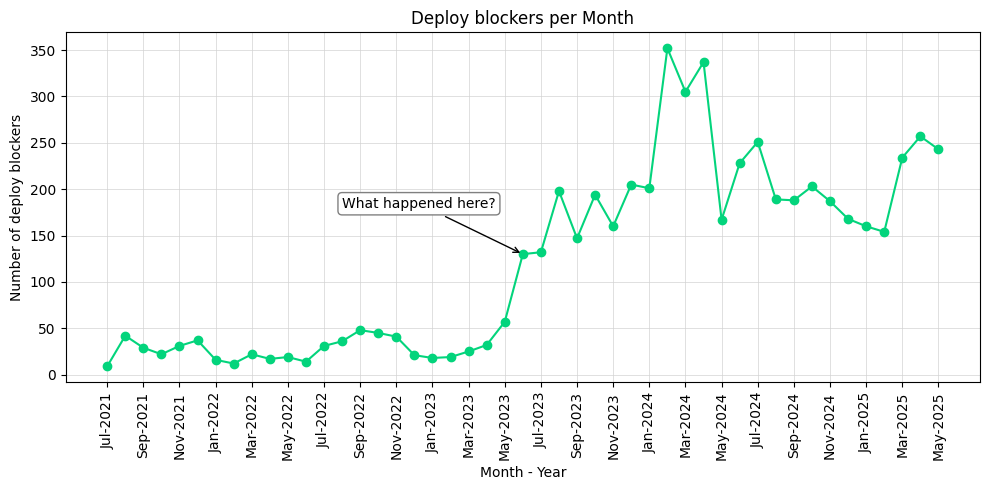

In [34]:
import calendar

# Create formatted month labels like 'Jul-2021'
formatted_labels = [
    f"{calendar.month_abbr[int(month)]}-{year}"
    for month, year in zip(blockers_per_month["Month"], blockers_per_month["Year"])
]


plt.figure(figsize=(10, 5))
plt.plot(
    formatted_labels,
    blockers_per_month["Deploy Blocker Count"],
    marker='o',
    linestyle='-',
    color='#03d47c'
)
plt.grid(True, color="#d3d3d3", linestyle='-', linewidth=0.5)


target_label = "Jun-2023"
target_index = formatted_labels.index(target_label)
target_value = blockers_per_month["Deploy Blocker Count"].iloc[target_index]

xtick_indices = list(range(0, len(formatted_labels), 2))
plt.xticks(
    ticks=xtick_indices,
    labels=[formatted_labels[i] for i in xtick_indices],
    rotation=0
)


plt.annotate(
    "What happened here?",
    xy=(target_index, target_value),
    xytext=(target_index - 10, target_value + 50),
    arrowprops=dict(facecolor='black', arrowstyle="->"),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1)
)



plt.title("Deploy blockers per Month")
plt.xlabel("Month - Year")
plt.ylabel("Number of deploy blockers")
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



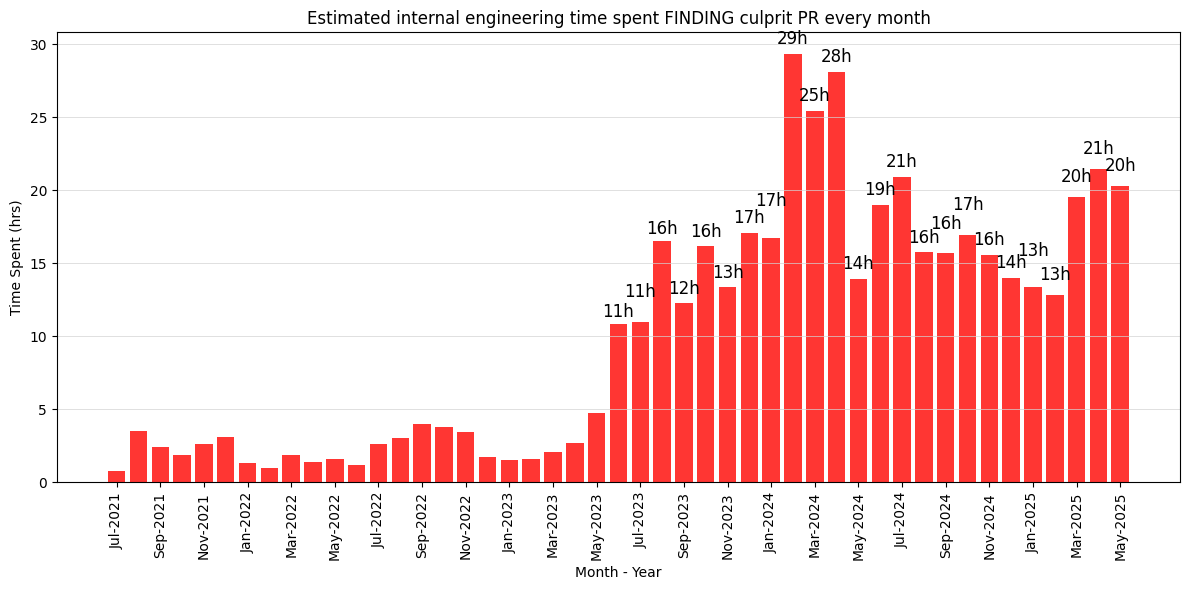

In [216]:
formatted_labels = [
    f"{calendar.month_abbr[int(month)]}-{year}"
    for month, year in zip(blockers_per_month["Month"], blockers_per_month["Year"])
]

def format_hours(val):
    return f"{val:.0f}h" if val >= 10 else f"{val:.1f}h"

plt.figure(figsize=(12, 6))
bars = plt.bar(formatted_labels, blockers_per_month["Time Spent (hrs)"], color="#FF3633")

# Custom x-ticks every 2 months
xtick_indices = list(range(0, len(formatted_labels), 2))
plt.xticks(
    ticks=xtick_indices,
    labels=[formatted_labels[i] for i in xtick_indices],
    rotation=90
)

# Manually tuned offsets (optional, keep or update as needed)
custom_offsets = [
    6, 10, 14, 8, 12, 16, 6, 14, 10, 6, 12, 10,
    6, 14, 12, 10, 4, 6, 8, 16, 8, 4, 4, 2,
    15, 2, 4, 4, 4, 4, 20, 4, 4, 4, 4, 4,
    4, 4, 15, 15, 4, 4, 20
]

# Annotate each bar with time spent
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height < 5:
        continue
    offset = custom_offsets[i] if i < len(custom_offsets) else 8
    plt.annotate(
        format_hours(height),
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=12,
        rotation=0
    )

plt.title("Estimated internal engineering time spent FINDING culprit PR every month")
plt.xlabel("Month - Year")
plt.ylabel("Time Spent (hrs)")
plt.grid(True, axis="y", color="#d3d3d3", linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()


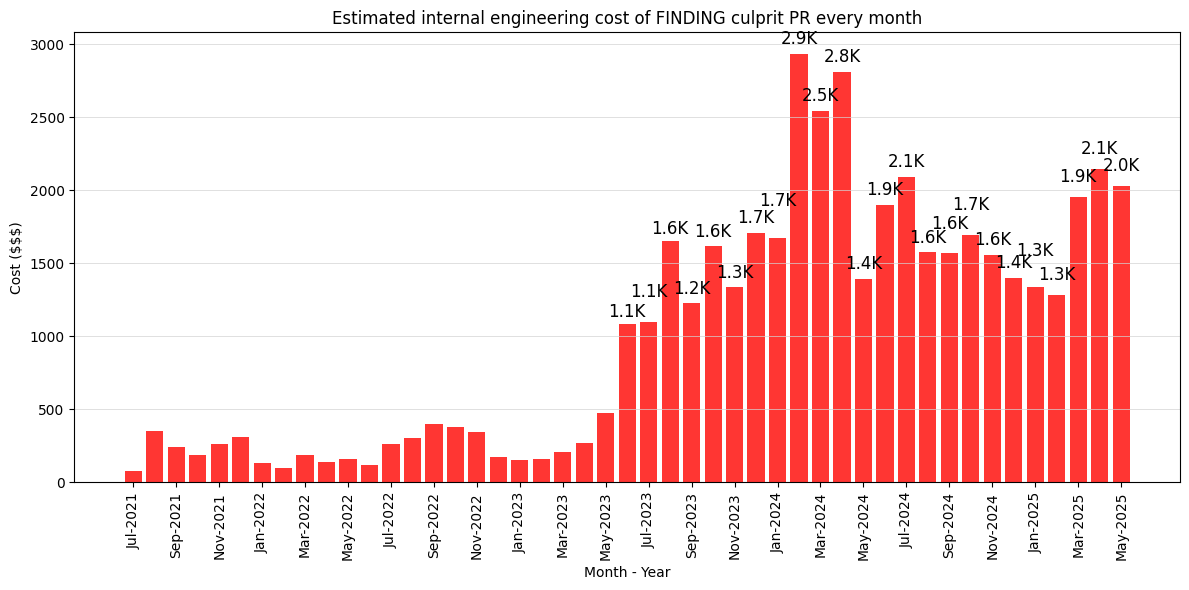

In [222]:
blockers_per_month["Time Spent (hrs)"] = blockers_per_month["Deploy Blocker Count"] * (5 / 60)
blockers_per_month["Cost ($)"] = blockers_per_month["Deploy Blocker Count"] * (5 / 60) * 100

# Create formatted month labels
formatted_labels = [
    f"{calendar.month_abbr[int(month)]}-{year}"
    for month, year in zip(blockers_per_month["Month"], blockers_per_month["Year"])
]



def format_dollar(val):
    return f"{val/1000:.1f}K" if val >= 1000 else f"{int(val)}"

plt.figure(figsize=(12, 6))
bars = plt.bar(formatted_labels, blockers_per_month["Cost ($)"], color="#FF3633")

# Custom x-ticks every 2 months
xtick_indices = list(range(0, len(formatted_labels), 2))
plt.xticks(
    ticks=xtick_indices,
    labels=[formatted_labels[i] for i in xtick_indices],
    rotation=90
)



custom_offsets = [
    6, 10, 14, 8, 12, 16, 6, 14, 10, 6, 12, 10,  # ← Adjust these manually
    6, 14, 12, 10, 4, 6, 8, 16, 8, 4, 4, 
    
    2, 
    15, 2, 4, 4, 4, 4, 20, 4, 4, 4, 4, 4,
    4, 4, 15, 15, 4, 4, 20
]


# Annotate cleanly with rotation & spacing
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height < 1000:
        continue
    offset = custom_offsets[i] if i < len(custom_offsets) else 8  
    plt.annotate(
        format_dollar(height),
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=12,
        rotation=0
    )

plt.title("Estimated internal engineering cost of FINDING culprit PR every month")
plt.xlabel("Month - Year")
plt.ylabel("Cost ($$$)")
plt.grid(True, axis="y", color="#d3d3d3", linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()



In [24]:
df["StagingDeployCash Created At"] = pd.to_datetime(df["StagingDeployCash Created At"])

df["Year-Week"] = df["StagingDeployCash Created At"].dt.strftime("%Y-%U")

blockers_per_week = df.groupby("Year-Week").size().reset_index(name="Deploy Blocker Count")

average_blockers_per_week = blockers_per_week["Deploy Blocker Count"].mean()
average_blockers_per_week


np.float64(29.036082474226806)

In [25]:
median_blockers_per_week = blockers_per_week["Deploy Blocker Count"].median()
median_blockers_per_week


np.float64(20.5)

In [26]:
# Extract Year-Month for grouping
df["Year-Month"] = df["StagingDeployCash Created At"].dt.to_period("M")

# Count blockers per month
blockers_per_month = df.groupby("Year-Month").size().reset_index(name="Deploy Blocker Count")

# Calculate average blockers per month
average_blockers_per_month = blockers_per_month["Deploy Blocker Count"].mean()
average_blockers_per_month


np.float64(119.85106382978724)

In [35]:
median_blockers_per_month = blockers_per_month["Deploy Blocker Count"].median()
median_blockers_per_month


np.float64(130.0)

In [78]:
cp_df = pd.read_csv("merged_cp_staging_prs.csv")
cp_df["date"] = pd.to_datetime(cp_df["date"])
cp_df = cp_df.drop_duplicates(subset="id")
cp_df.describe()

,id,date
count,1204.000000,1204
mean,43990.445183,2024-06-01 22:25:30.897009920
min,1213.000000,2021-01-12 00:00:00
25%,34585.000000,2024-01-17 12:00:00
50%,49828.500000,2024-09-28 12:00:00
75%,56364.000000,2025-02-05 00:00:00
max,63255.000000,2025-06-02 00:00:00
std,16953.199747,NaN


In [98]:
# this is without osbotify PRs

all_df = pd.read_csv("merged_all_prs.csv")
all_df["date"] = pd.to_datetime(all_df["merged_at"])
all_df = all_df.drop_duplicates(subset="id")
all_df.describe()

,id,date
count,20517.000000,20517
mean,33556.110445,2023-11-16 14:48:33.057464320
min,741.000000,2021-01-04 00:00:00
25%,18689.000000,2023-05-15 00:00:00
50%,34703.000000,2024-01-29 00:00:00
75%,48731.000000,2024-09-13 00:00:00
max,63282.000000,2025-06-03 00:00:00
std,17883.990107,NaN


In [105]:

all_monthly = all_df.groupby(all_df["date"].dt.to_period("M")).size().reset_index(name="Total Merged PRs")
cp_monthly = cp_df.groupby(cp_df["date"].dt.to_period("M")).size().reset_index(name="CP Staging PRs")

# drop june 2025, not enough data
all_monthly = all_monthly[~((all_monthly["date"].dt.year == 2025) & (all_monthly["date"].dt.month == 6))]
cp_monthly = cp_monthly[~((cp_monthly["date"].dt.year == 2025) & (cp_monthly["date"].dt.month == 6))]


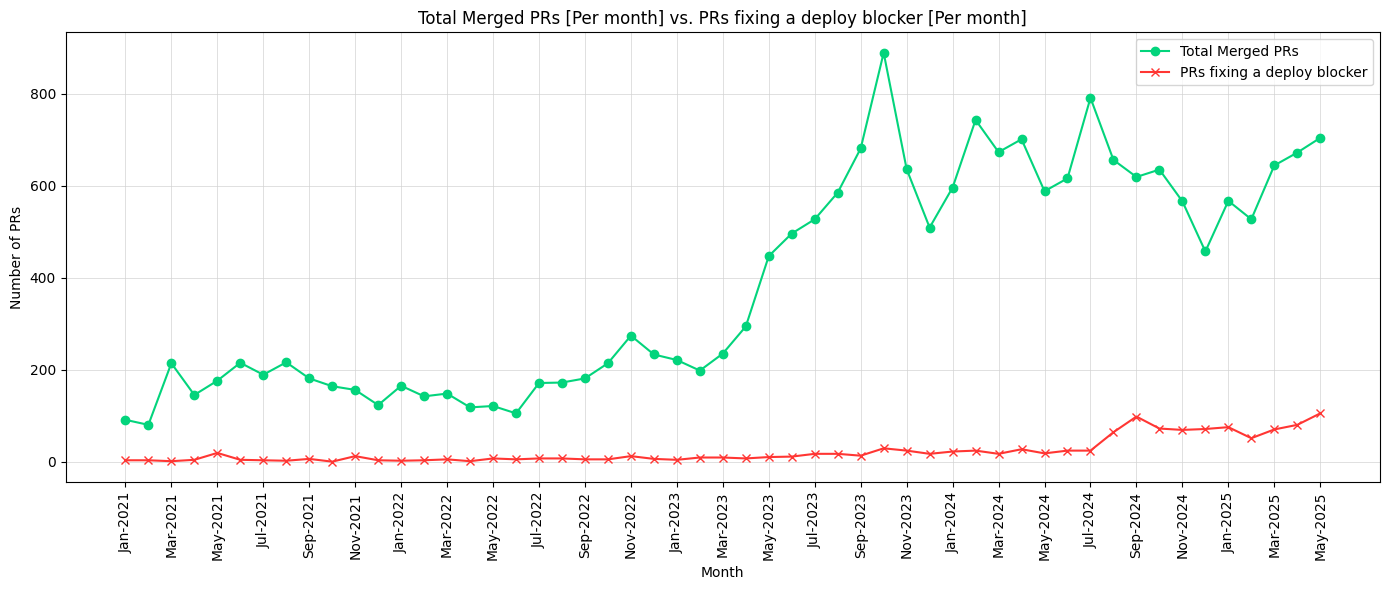

In [124]:
merged = pd.merge(all_monthly, cp_monthly, on="date", how="outer").sort_values("date")
merged = merged.fillna(0)
formatted_labels = [
    f"{calendar.month_abbr[period.month]}-{period.year}"
    for period in merged["date"]
]

plt.figure(figsize=(14, 6))
plt.plot(formatted_labels, merged["Total Merged PRs"], marker="o", label="Total Merged PRs", color="#03d47c")
plt.plot(formatted_labels, merged["CP Staging PRs"], marker="x", label="PRs fixing a deploy blocker", color="#FF3633")

plt.title("Total Merged PRs [Per month] vs. PRs fixing a deploy blocker [Per month]")
plt.xlabel("Month")
plt.ylabel("Number of PRs")
plt.grid(True, color="#d3d3d3", linestyle="-", linewidth=0.5)
plt.xticks(ticks=range(0, len(formatted_labels), 2), labels=formatted_labels[::2], rotation=90)

plt.legend()
plt.tight_layout()
plt.show()


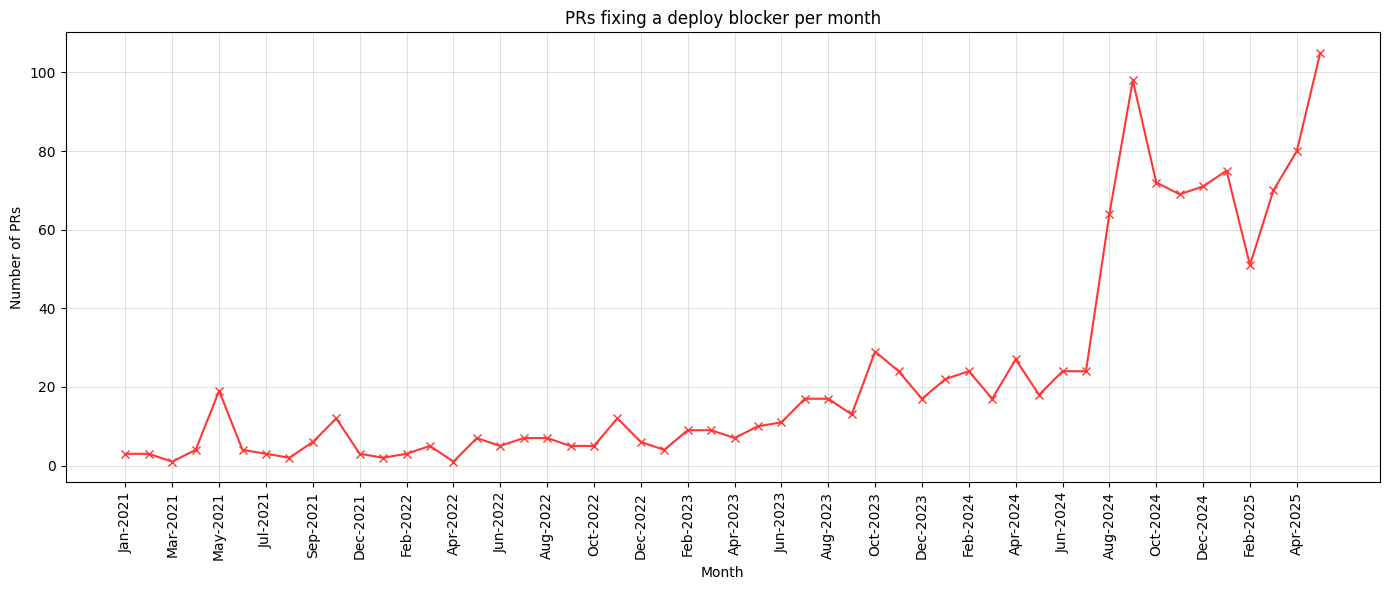

In [126]:
formatted_labels = [
    f"{calendar.month_abbr[int(period.month)]}-{period.year}"
    for period in monthly_all["date"]
]

plt.figure(figsize=(14, 6))
plt.plot(formatted_labels, monthly_all["All CPs"], marker="x", linestyle='-', color="#FF3633")

plt.title("PRs fixing a deploy blocker per month")
plt.xlabel("Month")
plt.ylabel("Number of PRs")
plt.grid(True, color="#d3d3d3", linestyle='-', linewidth=0.5)
plt.xticks(ticks=range(0, len(formatted_labels), 2), labels=formatted_labels[::2], rotation=90)

plt.tight_layout()
plt.show()


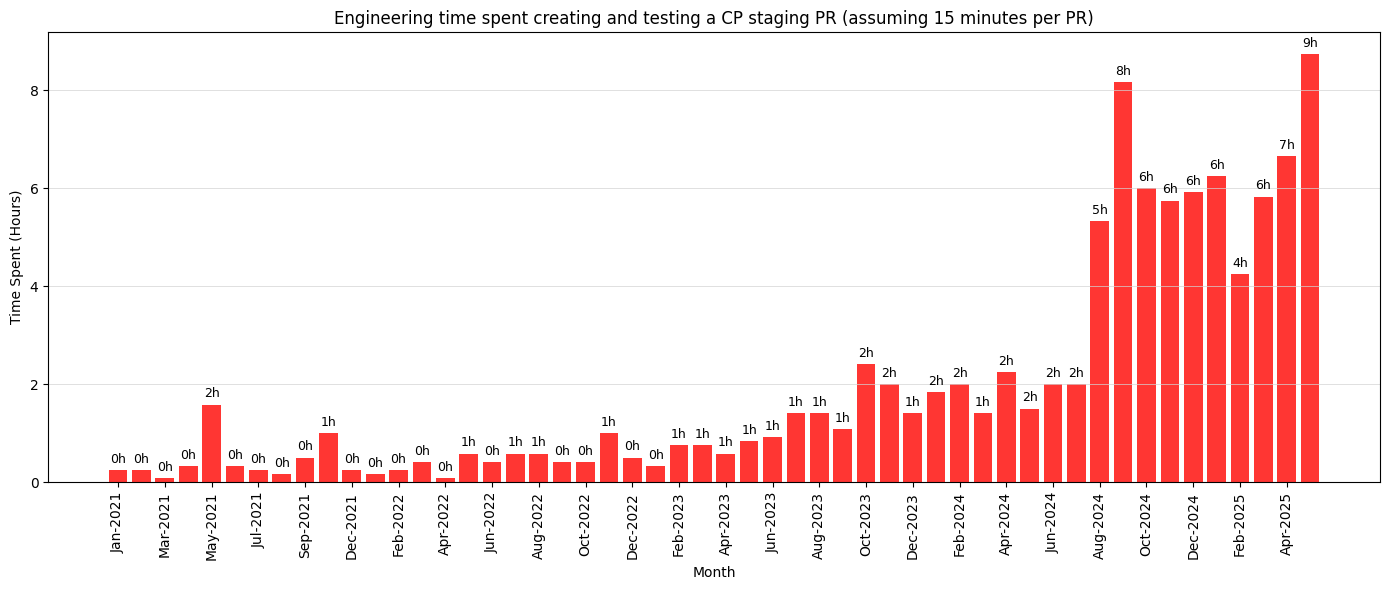

In [129]:
cp_monthly["Time Spent (hrs)"] = cp_monthly["CP Staging PRs"] * (5 / 60)

# Step 2: Format x-axis labels
formatted_labels = [
    f"{calendar.month_abbr[period.month]}-{period.year}"
    for period in cp_monthly["date"]
]

plt.figure(figsize=(14, 6))
bars = plt.bar(formatted_labels, cp_monthly["Time Spent (hrs)"], color="#FF3633")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{height:.0f}h",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Engineering time spent creating and testing a CP staging PR (assuming 15 minutes per PR)")
plt.xlabel("Month")
plt.ylabel("Time Spent (Hours)")
plt.grid(True, axis="y", color="#d3d3d3", linestyle="-", linewidth=0.5)
plt.xticks(ticks=range(0, len(formatted_labels), 2), labels=formatted_labels[::2], rotation=90)

plt.tight_layout()
plt.show()

